# 02 · Basics

Every program in the Introduction runs once. An experiment is a program repeated while something is varied, and three pieces turn one into the other. A **variable** is the hole in the program where the knob goes, a **sweep source** says how that knob moves, and **`average(shots)`** repeats the whole thing.

The other half of this notebook is the data. `qp.simulate` returns labeled arrays whose axes are named after the variables you declared, and which know enough to draw themselves.

Three worked examples close it out: one swept variable, two of them nested, and two of them stepping in lockstep.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0"], check=True)
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import IQDrag, IQZero, Square

schema = BusSchema.transmon()
q = schema.q

## 2.0 The numbers this notebook needs

The Introduction declared three constants and used them as literals in a program. This notebook sweeps past two of them and measures a third, so it needs two more.

`KAPPA` is the linewidth of the readout resonator, the full width at half maximum of its resonance in hertz. It sets how finely you have to step a frequency sweep to see the resonance at all. `RABI_RATE` says how strongly the drive couples to the qubit, in hertz of rotation rate per DAC unit of amplitude. It is the number that turns an amplitude on a cable into a rotation on the Bloch sphere, and it sets both how hard the qubit responds and how wide the response looks in frequency.

Every model that stands in for the chip in sections 2.6 to 2.9 is a short formula over these five numbers, and every figure in those sections comes out of a function you can read.

One thing is deliberately left out. Every `measure` below passes the string aliases `"readout"` and `"weights"` of section 1.5 rather than concrete shapes, and never binds them. The reference platform models measurements rather than pulses, so it never reads a readout envelope, and leaving the aliases unbound keeps the printed `.qp` text short enough to read. The measurement model is the only stand-in for the fridge.

In [3]:
F01 = 4.85e9  # Hz, the qubit 0 to 1 transition
F_READOUT = 7.20e9  # Hz, the readout resonator
A_PI = 0.62  # DAC units, the drive amplitude of a full 0 to 1 rotation
KAPPA = 1.5e6  # Hz, the readout resonator linewidth (full width at half maximum)
RABI_RATE = 40e6  # Hz per DAC unit, how fast the drive rotates the qubit

print(f"resonator {F_READOUT / 1e9:.3f} GHz, {KAPPA / 1e6:.1f} MHz wide")
print(f"a drive at amplitude {A_PI} rotates the qubit at {RABI_RATE * A_PI / 1e6:.1f} MHz")

resonator 7.200 GHz, 1.5 MHz wide
a drive at amplitude 0.62 rotates the qubit at 24.8 MHz


## 2.1 Variables

A variable is a named hole in a program, and you leave one for either of two reasons. You do not know the value yet, or you want to run the same program at a series of values.

Before any loop exists a variable is an ordinary object, and the whole of what it does is hold one number at a time. Start there, because a sweep does nothing to a variable that the cell below does not do by hand.

In [4]:
scratch = qp.QProgram(label="variables", schema=schema)
amp = scratch.variable("amp")

print("nothing bound yet:", amp.value)
amp.set_value(0.25)  # what a loop does once per iteration
print("after set_value: ", amp.value)
amp.reset()
print("after reset:     ", amp.value)

nothing bound yet: UNASSIGNED
after set_value:  0.25
after reset:      UNASSIGNED


### Declaring one

`program.variable(id, *, label=None, units=None, description=None)` is the full signature. Only the id is positional and required, and the other three are keyword-only.

The id is the one part that has to be machine-legible. It becomes the token in the `.qp` file and the dimension name in the result, so it has to match `[A-Za-z_][A-Za-z0-9_]*`, has to be unique on the program, and has to avoid the twenty-nine words in `qp.RESERVED_KEYWORDS`. All three rules raise at the declaration rather than later.

`label` and `units` are for people, and they travel with the data. The executor writes them onto the swept coordinate of every result array, where they become the axis label of every figure drawn from it. Declaring both at the declaration is the whole of plot labeling, done once and never repeated. `description` is longer prose for a reader, and it rides into the file and back out again without the result or the figure reading it.

In [5]:
freq = scratch.variable(
    "freq", label="Readout frequency", units="Hz", description="the tone sent down the feedline"
)

print("id / label / units:", freq.id, "|", freq.label, "|", freq.units)
print("declared so far:   ", [v.id for v in scratch.variables])

for bad_id, error in (("freq", qp.ValidationError), ("readout frequency", qp.InvalidVariableIdError)):
    try:
        scratch.variable(bad_id)
    except error as exc:
        print(f"\n{type(exc).__name__}:", exc)

id / label / units: freq | Readout frequency | Hz
declared so far:    ['amp', 'freq']

ValidationError: Variable 'freq' is already declared on this QProgram

InvalidVariableIdError: Variable id 'readout frequency' is invalid: must match [A-Za-z_][A-Za-z0-9_]* (letters, digits, underscores only; cannot start with a digit, no spaces or special characters). Use the optional `label` for human-readable names.


## 2.2 Expressions

An operator applied to a variable builds another node and computes nothing. Five families are available.

- `+`, `-`, `*` and `/`, with their reflected forms, build a `BinaryOp`. There is no power, floor division, or modulo.
- Unary `-` and `+` build a `UnaryOp`.
- `abs()` and the eight module functions `qp.sin`, `qp.cos`, `qp.tan`, `qp.exp`, `qp.log`, `qp.sqrt`, `qp.minimum` and `qp.maximum` build a `MathFunc`.
- `<`, `<=`, `>` and `>=` build a `Comparison`, and `qp.where(condition, then, else_)` turns one back into a value.
- `&`, `|` and `~` build a `LogicalBinaryOp` or a `LogicalNot`.

Equality is the one gap. `Variable.__eq__` has to keep returning a plain bool so that variables can live in a set, so the symbolic spellings are `qp.eq` and `qp.ne`. The `state` proxy a handle carries is under no such constraint, so the branch in the Advanced notebook is spelled `if_(handle.state == 1)`.

An expression also refuses to be a truth value, so `if amp > 0.5:` raises on the line that wrote it rather than quietly taking the object as true.

In [6]:
sketch = qp.QProgram(label="expressions", schema=schema)
detuning = sketch.variable("detuning", label="Detuning", units="Hz")

sketch.set_frequency(q[0].readout, detuning + F_READOUT)  # an expression, written into the tree
sketch.wait(q[0].readout, 4 * detuning)

print(qp.dumps(sketch).split("body:")[1].rstrip())

try:
    if amp > 0.5:
        pass
except TypeError as exc:
    print("\nan expression is not a truth value:", exc)


  var detuning label="Detuning" units="Hz"

  set_frequency q[0].readout (detuning + 7200000000.0)
  wait q[0].readout (4 * detuning)

an expression is not a truth value: Expression has no truth value — use .evaluate()/.evaluate_or_raise() to compute it, or qprogram.where(cond, then, else_) to build a conditional expression.


### Where an expression may appear

Anywhere QProgram takes a number. Among the operations that means `set_frequency`, `set_gain`, `set_phase`, both paths of `set_offset`, the value of `set_parameter`, and the duration of `wait`. Among the waveforms it means every numeric constructor argument of every parameterized shape, with the samples of `Arbitrary`, the shape a wrapper wraps, and `FlatTop`'s integer buffer as the exceptions.

`play` and `measure` take a waveform rather than a number, so an expression reaches a pulse through the waveform's constructor. A shape built that way computes nothing until `envelope()` is called on it, and section 2.8 sweeps a pulse amplitude exactly this way.

Two methods read an expression tree, and they differ in what they do about a hole. `evaluate()` returns `qp.UNASSIGNED` as soon as anything in the tree is unbound, and the sentinel propagates upward, so code inspecting a half-built program never has to guard. `evaluate_or_raise()` insists on a number instead. The interpreter calls that one before running an operation, so a variable no enclosing loop binds becomes an error rather than a silent zero.

In [7]:
tone = Square(amplitude=amp / 2, duration=8)
amp.set_value(0.8)
print("the shape computes on demand:", tone.envelope())
amp.reset()
print("and reports the hole once the value is gone:", tone.amplitude.evaluate())

orphan = qp.QProgram(label="unbound", schema=schema)
loose = orphan.variable("loose")
orphan.set_gain(q[0].readout, loose)  # nothing will ever bind it
try:
    qp.simulate(orphan)
except qp.UnassignedVariableError as exc:
    print("\nat run time:", exc)

the shape computes on demand: [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
and reports the hole once the value is gone: UNASSIGNED

at run time: Cannot evaluate expression Variable('loose'): unassigned variable(s) {Variable('loose')}


## 2.3 Sweeps

A variable left alone stays unassigned, and `program.sweep(variable, source)` binds it. The block runs its body once per value, writing that value into the variable first, so every operation inside sees the current one.

The values are not part of the block. They come from a **source**, and a source is to a sweep what a waveform is to a `play`: a small immutable value object that serializes into the `.qp` file and carries its own capability tokens. One loop type covers every shape of values because the shape lives in the source.

In [8]:
tiny = qp.QProgram(label="smallest_sweep", schema=schema)
gain = tiny.variable("gain")

with tiny.sweep(gain, qp.Values([0.1, 0.2, 0.3])):
    tiny.set_gain(q[0].readout, gain)

print(qp.dumps(tiny).split("body:")[1].rstrip())


  var gain

  for gain in [0.1, 0.2, 0.3]:
    set_gain q[0].readout gain


### The two spellings

Leave the source out and `sweep` hands back a builder whose `from_*` methods make one for you instead.

An unknown `from_<name>` resolves against the live sweep-source registry rather than a fixed list, so a source registered by a vendor extension gets its builder with no change to the core. Both spellings build the same node and write the same `.qp` line, so pick by what the call site is doing. Reach for `from_*` when you are typing the numbers out, and pass the object when the source is computed or when you want to read its properties.

A bare list is refused rather than taken as a shorthand. A source declares its kind and its capability token before the program runs, so a platform can tell a ramp from a table without running anything, and a list of floats declares neither.

In [9]:
fluent = qp.QProgram(label="smallest_sweep", schema=schema)
g_fluent = fluent.variable("gain")
with fluent.sweep(g_fluent).from_values([0.1, 0.2, 0.3]):
    fluent.set_gain(q[0].readout, g_fluent)

print("same tree:", tiny.body == fluent.body)
print("same text:", qp.dumps(tiny) == qp.dumps(fluent))

try:
    with tiny.sweep(gain, [0.1, 0.2, 0.3]):
        pass
except qp.ValidationError as exc:
    print("\na bare list:", exc)

same tree: True
same text: True

a bare list: Sweep source must be a SweepSource, got [0.1, 0.2, 0.3]


### The sources

Eight ship, and every one is reachable both ways.

| Source | What it is |
|---|---|
| `qp.Range(start, stop, step=1)` | a ramp given by its spacing |
| `qp.Linspace(start, stop, num)` | a ramp given by its point count |
| `qp.Values(points)` | an explicit list, anything `numpy.asarray` takes |
| `qp.Logspace(start, stop, num)` | `num` points log spaced between two real bounds, not exponents |
| `qp.File(path)` | the points in a `.npy`, stored as the path and re-read on every access |
| `qp.Repeat(source, times)` | one source, run through `times` times over |
| `qp.Rotate(source, by=1)` | one source, shifted cyclically left |
| `qp.Concat(sources)` | several sources, end to end |

The last three take a source and hand back a source, so they compose with each other and with the five above. The fluent spelling reaches two of them by chaining, so `.rotate(by=...)` and `.repeat(...)` hang off a sweep that already has values.

In [10]:
base = qp.Values([0.0, 0.5, 1.0])
sources = [
    qp.Range(0.0, 1.0, 0.25),
    qp.Linspace(0.0, 1.0, 5),
    qp.Logspace(0.01, 1.0, 5),
    qp.Repeat(base, 2),
    qp.Rotate(base, by=1),
    qp.Concat([base, qp.Linspace(2.0, 3.0, 3)]),
]

for source in sources:
    print(f"{type(source).__name__:9} {source.length():2d} points  {np.round(source.values(), 3)}")

chained = qp.QProgram(label="chained_source", schema=schema)
g_chain = chained.variable("gain")
with chained.sweep(g_chain).from_values([0.1, 0.2, 0.3]).rotate(by=1).repeat(2):
    chained.set_gain(q[0].readout, g_chain)

print("\nrotated once, then run through twice:")
print(qp.dumps(chained).split("body:")[1].rstrip())

Range      5 points  [0.   0.25 0.5  0.75 1.  ]
Linspace   5 points  [0.   0.25 0.5  0.75 1.  ]
Logspace   5 points  [0.01  0.032 0.1   0.316 1.   ]
Repeat     6 points  [0.  0.5 1.  0.  0.5 1. ]
Rotate     3 points  [0.5 1.  0. ]
Concat     6 points  [0.  0.5 1.  2.  2.5 3. ]

rotated once, then run through twice:

  var gain

  for gain in Repeat(source=Rotate(source=[0.1, 0.2, 0.3], by=1), times=2):
    set_gain q[0].readout gain


### Linear and arbitrary

Every source carries two class attributes a platform reads without running anything. `KIND` is either `"linear"` or `"arbitrary"`, and `TOKEN` is the capability name a platform accepts or refuses.

`"linear"` is a promise about the values. Point $i$ is exactly `start + step * i`, and that promise is the whole of what an instrument needs to generate the points itself. `"arbitrary"` is every other source, and its points have to reach the instrument as a table or one at a time from the host.

`qp.Values` is arbitrary **even when the numbers you pass are evenly spaced**, because a list of floats proves nothing about its own regularity. If your sweep really is a ramp, say `qp.Range` or `qp.Linspace`. The kind also degrades: a combinator is arbitrary whatever it wraps, and it still asks for everything its children ask for. The Advanced notebook is where a rack reads these declarations and decides.

`qp.Range` is worth one more line, because it counts its own points. It holds `round((stop - start) / step) + 1` of them and lands on `stop` only when the step divides the span evenly.

In [11]:
for source in (qp.Range(0.0, 1.0, 0.25), qp.Linspace(0.0, 1.0, 5), base, qp.Concat([base])):
    print(f"{type(source).__name__:9} {source.KIND:10} {sorted(source.tokens())}")

print("\nRange(0, 10, 2) lands on stop: ", qp.Range(0, 10, 2).values())
print("Range(0, 10, 3) stops short:   ", qp.Range(0, 10, 3).values())

try:
    qp.Range(0, 10, -2)  # a step pointing away from stop
except qp.ValidationError as exc:
    print("\nrefused at construction:", exc)

Range     linear     ['sweep.linear', 'sweep.range']
Linspace  linear     ['sweep.linear', 'sweep.linspace']
Values    arbitrary  ['sweep.arbitrary', 'sweep.values']
Concat    arbitrary  ['sweep.arbitrary', 'sweep.concat', 'sweep.values']

Range(0, 10, 2) lands on stop:  [ 0.  2.  4.  6.  8. 10.]
Range(0, 10, 3) stops short:    [0. 3. 6. 9.]

refused at construction: Range step -2.0 moves away from stop (0.0 -> 10.0); flip the step sign or swap the bounds


## 2.4 The measurement model

The interpreter asks a **measurement model** for one sample per shot per `measure`, and every measured number in a run comes from it. It receives the bus being measured and `env`, a mapping of every variable that currently holds a number, keyed by id, plus the platform parameter store keyed as `"bus.parameter"`. A variable that no enclosing loop has bound is absent from `env` rather than zero, so a model reaching for one fails loudly.

`qp.MockMeasurementModel(response=None, p_excited=None, noise=0.0, raw_samples=16, seed=0)` covers most cases, and every default does something. No `response` answers `0j`, no `p_excited` keeps every shot in the ground state, `noise` is the per-quadrature gaussian sigma applied per shot, and `seed` feeds one private generator, so a fresh model at the same seed replays the same numbers where one model reused across two runs does not.

The cell below prints what a model is actually handed, once per shot per point.

In [12]:
seen = []


def peek(bus, env):
    """A response function that records what it was asked, then returns a flat signal."""
    seen.append((str(bus), dict(env)))
    return 1 + 0j


probe = qp.QProgram(label="env_probe", schema=schema)
p_amp = probe.variable("ro_amp", units="DAC units")
p_freq = probe.variable("ro_freq", units="Hz")

with probe.average(shots=2):
    with probe.sweep(p_amp, qp.Values([0.1, 0.4])):
        with probe.sweep(p_freq, qp.Linspace(7.19e9, 7.21e9, 3)):
            probe.measure(q[0].readout, "readout", "weights")

qp.simulate(probe, model=qp.MockMeasurementModel(response=peek))

print("samples requested:", len(seen), "= 2 shots x 2 amplitudes x 3 frequencies")
print("bus:", seen[0][0])
print("env:", seen[0][1])

samples requested: 12 = 2 shots x 2 amplitudes x 3 frequencies
bus: q0/readout
env: {'ro_amp': 0.1, 'ro_freq': 7190000000.0}


### Writing your own

`qp.MockMeasurementModel` is a convenience over a two-line protocol, and reaching past it takes no ceremony. A model is any object with a `sample(bus, env)` method returning a `qp.MeasurementSample`, which carries `i`, `q`, `state`, and an optional `raw` trace. Set a `raw_samples` attribute when the model simulates an ADC, and the executor reads it once at the start of a run.

Reach for your own class when the response has state in it, when two buses answer from shared bookkeeping, or when the classified outcome and the integrated point have to agree in a way the mock's two independent callbacks cannot express.

In [13]:
class TwoStateReadout:
    """Two IQ clouds, one per qubit state, with the state drawn first so the two agree."""

    def __init__(self, p_excited, seed=0):
        self.p_excited = p_excited
        self.rng = np.random.default_rng(seed)

    def sample(self, bus, env):
        state = int(self.rng.random() < self.p_excited(bus, env))
        centre_i, centre_q = (0.9, 0.1) if state else (0.2, -0.3)
        spread = self.rng.normal(0.0, 0.08, 2)
        return qp.MeasurementSample(i=centre_i + spread[0], q=centre_q + spread[1], state=state)


one_point = qp.QProgram(label="own_model", schema=schema)
m_own = one_point.measure(
    q[0].readout, "readout", "weights", fields=(MeasurementField.IQ, MeasurementField.STATE)
)
own = qp.simulate(one_point, model=TwoStateReadout(lambda bus, env: 1.0, seed=1))

print("one shot of the excited cloud:", np.round(own.get(m_own).values, 3))
print("and its classified state:     ", float(own.get(m_own, field=MeasurementField.STATE)))

one shot of the excited cloud: [0.966 0.126]
and its classified state:      1.0


## 2.5 `average(shots)` adds no dimension

`with program.average(shots=N)` wraps a block and repeats it. The integrated point and the raw trace come back as means over the shots, the classified state comes back as the excited-state population, and the shot count appears nowhere in the shape of the result.

Adding no dimension is not the same as costing nothing. `average` is a repeating block exactly as a sweep is, so it adds a level to the repetition depth a machine has to support. The Advanced notebook is where a rack declares how deep it will go, under the name `max_loop_nesting`.

In [14]:
def flat_scan(shots):
    """Measure a constant noisy signal 64 times, averaged `shots` deep."""
    program = qp.QProgram(label=f"flat_{shots}", schema=schema)
    index = program.variable("idx")
    with program.average(shots=shots):
        with program.sweep(index, qp.Range(0, 63, 1)):
            handle = program.measure(q[0].readout, "readout", "weights")
    model = qp.MockMeasurementModel(response=lambda bus, env: 1 + 0j, noise=0.5, seed=5)
    return qp.simulate(program, model=model).get(handle)


for shots in (1, 4, 64, 256):
    scan = flat_scan(shots)
    print(f"shots={shots:4d}  dims={scan.dims}  shape={scan.shape}  "
          f"std(I)={scan.sel(IQ='I').values.std():.4f}")

shots=   1  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.5473
shots=   4  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.2596
shots=  64  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0664


shots= 256  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0305


The shape never changes and only the spread does. Doubling the shots buys a factor of 1.4 in noise for twice the measurement time, so shots are the last knob to turn: a readout frequency placed on the resonance costs nothing per shot.

Averaging does something different to the classified state. One shot is classified 0 or 1, so one shot gives you a bit. Average five hundred and the same array position holds a population. Nothing about the array shape says which of the two you are holding, because the shot count decides and the shot count is not in the result.

In [15]:
def population_scan(shots):
    """Five repeats of a measurement on a qubit that is excited 30 percent of the time."""
    program = qp.QProgram(label=f"pop_{shots}", schema=schema)
    rep = program.variable("rep")
    with program.average(shots=shots):
        with program.sweep(rep, qp.Range(0, 4, 1)):
            handle = program.measure(
                q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,)
            )
    biased = qp.MockMeasurementModel(p_excited=lambda bus, env: 0.3, seed=9)
    return qp.simulate(program, model=biased).get(handle, field=MeasurementField.STATE)


print("shots=1   ->", population_scan(1).values, "  one classified shot per point")
print("shots=500 ->", population_scan(500).values, "  the same shape, now a population")

shots=1   -> [0. 1. 0. 0. 0.]   one classified shot per point
shots=500 -> [0.27  0.318 0.308 0.258 0.304]   the same shape, now a population


## 2.6 One swept variable

Everything above assembled. The experiment steps the readout frequency across the resonator and records what comes back at every step, which is how the resonator is found on a new chip in the first place. A resonator hung off a feedline shows up as a notch in transmission,

$$ S_{21}(f) = 1 - \frac{0.9}{1 + i\,\delta}, \qquad \delta = \frac{f - f_r}{\kappa / 2} $$

so the model is one line of arithmetic over `F_READOUT` and `KAPPA`. The window is 20 MHz wide in 200 kHz steps, which puts about seven samples across a resonance 1.5 MHz wide.

In [16]:
def s21(bus, env):
    """Transmission past one resonator: a notch, 90 percent deep on resonance."""
    delta = (env["ro_freq"] - F_READOUT) / (KAPPA / 2)
    return 1.0 - 0.9 / (1.0 + 1j * delta)


spectroscopy = qp.QProgram(
    label="resonator_spectroscopy", description="Find the readout resonator.", schema=schema
)
ro_freq = spectroscopy.variable("ro_freq", label="Readout frequency", units="Hz")

with spectroscopy.average(shots=200):
    with spectroscopy.sweep(ro_freq, qp.Range(7.19e9, 7.21e9, 0.2e6)):
        spectroscopy.set_frequency(q[0].readout, ro_freq)
        m_spec = spectroscopy.measure(q[0].readout, "readout", "weights")

print(qp.dumps(spectroscopy))

#!QProgram 1.0

metadata:
  label: "resonator_spectroscopy"
  description: "Find the readout resonator."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 200:
    for ro_freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



In [17]:
result = qp.simulate(spectroscopy, model=qp.MockMeasurementModel(response=s21, noise=0.02, seed=7))
iq = result.get(m_spec)

print("dims:", iq.dims, "shape:", iq.shape)

dims: ('ro_freq', 'IQ') shape: (101, 2)


One hundred and one frequencies by two quadratures. The two hundred shots are gone, because `average` collapsed them.

### The result model

`qp.simulate` returns a `qp.QProgramResult`, which holds one record per `measure` in the program, in the order they were declared. Each record carries the bus it ran on, the name `measure` allocated, and the fields that measurement asked for.

In [18]:
print(result)
for record in result.measurements:
    print("  ", record.bus, record.name, sorted(record.fields))

QProgramResult(1 measurements, names=['q0/readout/m0'])
   q0/readout q0/readout/m0 ['iq']


`result.get(measurement, bus=None, field=MeasurementField.IQ)` pulls one array out, and it resolves three spellings of the first argument. A handle says what it means and is the one to prefer. A plain name string selects the same record, and you reach for that after loading a program back from a `.qp` file in a session that never built it. An integer is positional sugar for declaration order. `bus=` narrows the candidates before any of the three is resolved, the thing a program measuring several qubits in one sweep needs, and `result.plot` takes all three spellings too.

`field=` defaults to the integrated point. Ask for a field the measurement never requested and you get a `KeyError`, the default included, so a measurement declared with `fields=(MeasurementField.STATE,)` needs `field=MeasurementField.STATE` spelled out.

What comes back is an `xarray.DataArray`. Its dimensions are the enclosing sweeps, outermost first, named after your variable ids, with the swept values as coordinates, and an integrated measurement carries one extra `IQ` axis of length two. The label and the units you declared arrive as attributes on the coordinate, which is where every axis label in this notebook comes from.

In [19]:
print("by handle:", result.get(m_spec).shape,
      "| by name:", result.get("q0/readout/m0").shape,
      "| by position:", result.get(0).shape)
print("what the variable left on the coordinate:", iq.coords["ro_freq"].attrs)

# Label-based selection is the point of xarray: no index arithmetic, no guessing the axis order.
on_resonance = iq.sel(IQ="I").sel(ro_freq=F_READOUT, method="nearest")
print("I at the resonator:", round(float(on_resonance), 4))

try:
    # this measurement asked for the integrated point and nothing else
    result.get(m_spec, field=MeasurementField.STATE)
except KeyError as exc:
    print("a field that was never requested:", exc)

by handle: (101, 2) | by name: (101, 2) | by position: (101, 2)
what the variable left on the coordinate: {'long_name': 'Readout frequency', 'units': 'Hz'}
I at the resonator: 0.1005
a field that was never requested: "Measurement 'q0/readout/m0' has no field 'state'; available: iq"


### Reading the numbers off

The dip position comes straight out of the array. `argmin` on the magnitude gives the centre to one step of the grid, so a 200 kHz grid gives the resonator to 200 kHz, and a finer answer costs either a finer grid or a fit to the shape of the curve.

In [20]:
freqs = iq.coords["ro_freq"].values
magnitude = np.abs(iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values)
f_dip = freqs[magnitude.argmin()]

print(f"dip at   {f_dip / 1e9:.6f} GHz")
print(f"true     {F_READOUT / 1e9:.6f} GHz")
print(f"the sweep steps {(freqs[1] - freqs[0]) / 1e3:.0f} kHz, which bounds what an argmin can say")

dip at   7.200000 GHz
true     7.200000 GHz
the sweep steps 200 kHz, which bounds what an argmin can say


## 2.7 Drawing a result

`result.plot(handle)` looks the array up exactly as `result.get(handle)` does and lets the shape choose the figure. One swept dimension besides `IQ` makes a line, and two make a heatmap. Nothing in the bare call below names an axis: the variable was declared with a label and a unit, both rode out to the coordinate, and the figure reads them off it.

Two lines come back because `channels` defaults to the pair of quadratures. `channels="magnitude"` takes the hypotenuse and draws one curve instead, `channels="phase"` draws the argument, and the y axis renames itself to match. Magnitude flattens out when a dip is shallow and phase stays readable there, so the two are worth having both.

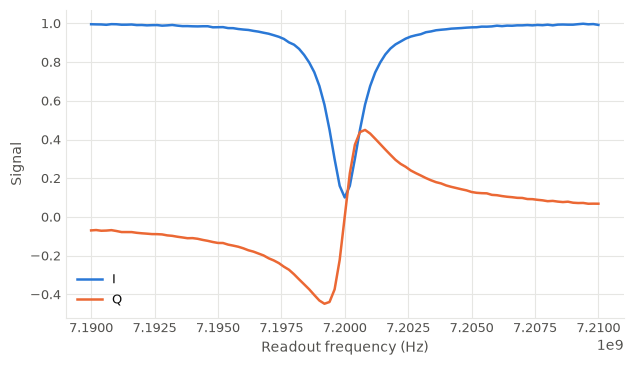

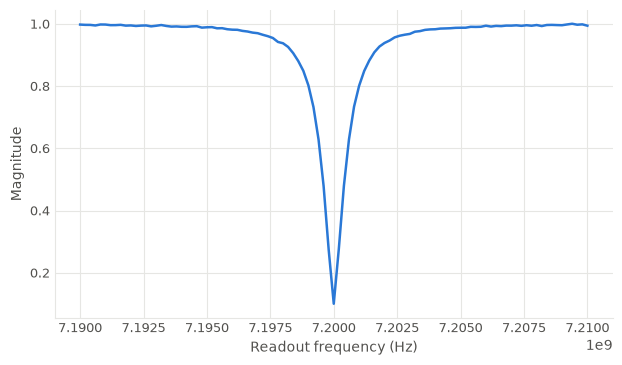

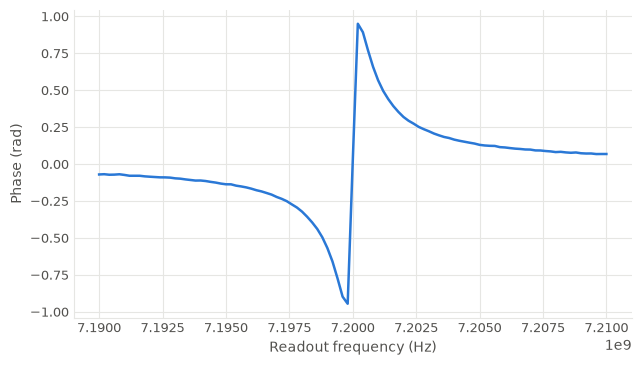

In [21]:
result.plot(m_spec)
plt.show()

result.plot(m_spec, channels="magnitude")
plt.show()

result.plot(m_spec, channels="phase")
plt.show()

Everything past the bare call is a decision about the figure rather than about the data, and each one is either an argument you add or a method on the `Axes` that came back.

`coords=` restates a coordinate for the figure alone and leaves the stored array untouched, and `Quantity(label, units, transform)` reads positionally in that order. A frequency axis wants gigahertz, and the restatement is a pair wherever there is a claim to falsify: on a coordinate that already declares `units="Hz"`, a transform alone would move the numbers under a label that still says hertz, and a unit alone would relabel numbers nobody moved. Both halves or neither.

Because the drawn numbers moved, everything you hand the returned `Axes` afterwards is in the figure's units too, so both reference lines below are divided by `1e9`. `value=` restates the measured quantity the same way, and `style=` carries the choices about the drawing itself, so `Style(markers=True)` puts a marker at every sample. The thin red line sits inside the thick grey one because `F_READOUT` is one of the 101 frequencies the sweep visits, so the argmin lands on it exactly.

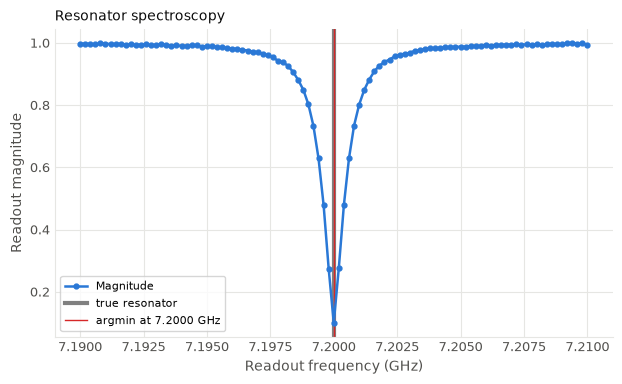

In [22]:
ax = result.plot(
    m_spec,
    channels="magnitude",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    style=Style(markers=True),
    title="Resonator spectroscopy",
)
ax.axvline(F_READOUT / 1e9, color="grey", lw=3, label="true resonator")
ax.axvline(f_dip / 1e9, color="tab:red", lw=1, label=f"argmin at {f_dip / 1e9:.4f} GHz")
ax.legend(fontsize=8)
plt.show()

In [23]:
try:
    result.plot(m_spec, coords={"ro_freq": Quantity(transform=lambda v: v / 1e9)})
except qp.ValidationError as exc:
    print(exc, "\n")

try:
    result.plot(m_spec, coords={"ro_freq": Quantity(units="GHz")})
except qp.ValidationError as exc:
    print(exc)

coords['ro_freq'] rescales the values, so the inherited unit 'Hz' no longer describes them and the axis would read (Hz) over numbers that are not in Hz. Pass units= for what they are now, units='' if they are now a bare ratio, or units='Hz' if the transform leaves the unit alone, as subtracting a baseline does. 

coords['ro_freq'] relabels the unit from 'Hz' to 'GHz' without changing the numbers, so the axis would read (GHz) over values still in Hz. Pass the transform= that converts them, or correct the unit on the variable the coordinate came from.


## 2.8 Two nested sweeps

Two `with` statements nest two loops, and nesting in the file is nesting in the result. The outer sweep becomes the outer dimension, and shots times points is the number to keep an eye on in the simulator and on real hardware alike.

The experiment finds the qubit. A weak tone is parked on the drive line and its frequency stepped, and where it hits the transition the qubit spends part of its time excited, which the readout reports as a population. Repeating that scan at a series of drive amplitudes turns one line into a map, and the map shows what amplitude does to the width. The peak is one half at every amplitude, and a stronger drive broadens the line, because the response is a Lorentzian whose width is the rotation rate itself,

$$ P_1(f, a) = \frac{1}{2}\,\frac{\Omega^2}{\Omega^2 + (f - f_{01})^2}, \qquad \Omega = \texttt{RABI\_RATE} \times a $$

The outer variable goes into the pulse rather than into an operation, so section 2.2's expression in a waveform constructor is here doing a real job.

In [24]:
def p_saturated(bus, env):
    """Excited-state population under a drive of amplitude `drive_amp`, detuned from F01."""
    rabi = RABI_RATE * env["drive_amp"]
    return 0.5 * rabi**2 / (rabi**2 + (env["drive_freq"] - F01) ** 2)


two_tone = qp.QProgram(label="qubit_spectroscopy", description="Find the qubit.", schema=schema)
drive_amp = two_tone.variable("drive_amp", label="Drive amplitude", units="DAC units")
drive_freq = two_tone.variable("drive_freq", label="Drive frequency", units="Hz")

with two_tone.average(shots=200):
    with two_tone.sweep(drive_amp, qp.Linspace(0.05, 0.30, 21)):
        with two_tone.sweep(drive_freq, qp.Linspace(F01 - 20e6, F01 + 20e6, 41)):
            two_tone.set_frequency(q[0].drive, drive_freq)
            two_tone.play(q[0].drive, IQZero(Square(amplitude=drive_amp, duration=20_000)))
            two_tone.sync([q[0].drive, q[0].readout])
            m_two_tone = two_tone.measure(
                q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,)
            )

print("points:", 21 * 41, "at 200 shots =", 21 * 41 * 200, "samples")

points: 861 at 200 shots = 172200 samples


In [25]:
map_result = qp.simulate(two_tone, model=qp.MockMeasurementModel(p_excited=p_saturated, seed=11))
population = map_result.get(m_two_tone, field=MeasurementField.STATE)

print("dims:", population.dims, "shape:", population.shape, "(outermost sweep first)")

dims: ('drive_amp', 'drive_freq') shape: (21, 41) (outermost sweep first)


Two swept dimensions make a heatmap, with one number per cell on the colour bar. The inner sweep runs along x and the outer up y, matching the loop nesting, so frequency comes out left to right and amplitude upward without either being asked for. `x=` and `y=` override that, and naming one settles the other.

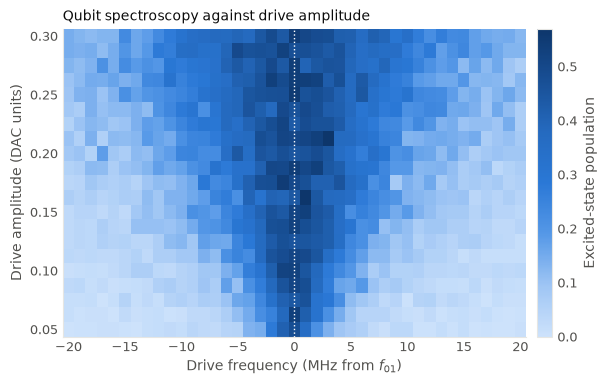

In [26]:
ax_map = map_result.plot(
    m_two_tone,
    field=MeasurementField.STATE,
    coords={"drive_freq": Quantity("Drive frequency", "MHz from $f_{01}$", lambda v: (v - F01) / 1e6)},
    value=Quantity("Excited-state population"),
    title="Qubit spectroscopy against drive amplitude",
)
ax_map.axvline(0.0, color="w", ls=":", lw=1)
plt.show()

The ridge sits on the transition at every amplitude and widens upward. Turning that into a number is two lines of numpy on the array, and the formula above predicts what the number should be: the response falls to half its peak exactly one rotation rate away from resonance, so the measured full width should come out at twice the rotation rate.

In [27]:
amps = population.coords["drive_amp"].values
scan = population.coords["drive_freq"].values
rows = population.values

print("amplitude   measured width   2 x rotation rate")
for row in (0, 10, 20):
    above = scan[rows[row] >= 0.25]  # half of the ceiling of one half
    print(f"    {amps[row]:.3f}      {(above[-1] - above[0]) / 1e6:5.1f} MHz"
          f"          {2 * RABI_RATE * amps[row] / 1e6:5.1f} MHz")

amplitude   measured width   2 x rotation rate
    0.050        3.0 MHz            4.0 MHz
    0.175       14.0 MHz           14.0 MHz
    0.300       24.0 MHz           24.0 MHz


The two upper rows agree exactly and the lowest one reads 3 MHz against a predicted 4. The sweep steps 1 MHz, and a width measured by counting which samples clear a threshold cannot land between two samples, so the narrowest line in the map is the one the grid resolves worst. Choosing a grid is choosing which part of the answer you are willing to quantise.

## 2.9 Two sweeps in lockstep

The map cost a rectangle of measurements and most of them sat off resonance. Now that the ridge has been found, you can walk along it instead, stepping two variables **together**, one point per row.

`sweep(a, source) | sweep(b, source)` is that lockstep pair. Both loops advance on the same tick over one shared body, so they must have the same length, and every source reports its length without running. The `|` itself computes nothing and modifies nothing, so the check fires when the block opens rather than on the line that composed it. That purity is the point rather than an accident, since it is what lets a list of sweeps be folded together and what lets a third `|` chain a third loop.

In the result the pair shares one dimension whose name joins the ids, carrying one coordinate array per composed variable. Point $k$ of one is always paired with point $k$ of the other, and there is no grid. The block it builds is a `Parallel`, which keeps its loops on `.loops` while `.elements` holds the shared body.

In [28]:
mismatched = qp.QProgram(label="mismatched", schema=schema)
a = mismatched.variable("a")
b = mismatched.variable("b")

pair_of_loops = mismatched.sweep(a, qp.Linspace(0, 1, 5)) | mismatched.sweep(b, qp.Linspace(0, 1, 6))
print("composing the two loops raised nothing, even though their lengths differ")

try:
    with pair_of_loops:
        pass
except qp.ValidationError as exc:
    print("caught when the block opens:", exc)

composing the two loops raised nothing, even though their lengths differ
caught when the block opens: parallel loops must have the same number of iterations to advance in lockstep; got Sweep('a'): 5, Sweep('b'): 6


The ridge below is the peak frequency of each row of the map, read off the array. Walking it takes 21 measurements against 861 for the full rectangle, and a diagonal earns its place whenever the interesting region is a curve rather than a rectangle.

In [29]:
ridge_freqs = scan[rows.argmax(axis=1)]

ridge = qp.QProgram(label="qubit_ridge", schema=schema)
r_amp = ridge.variable("drive_amp", label="Drive amplitude", units="DAC units")
r_freq = ridge.variable("drive_freq", label="Drive frequency", units="Hz")

with ridge.average(shots=200):
    with ridge.sweep(r_amp, qp.Values(amps)) | ridge.sweep(r_freq, qp.Values(ridge_freqs)):
        ridge.set_frequency(q[0].drive, r_freq)
        ridge.play(q[0].drive, IQZero(Square(amplitude=r_amp, duration=20_000)))
        ridge.sync([q[0].drive, q[0].readout])
        m_ridge = ridge.measure(q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,))

In [30]:
ridge_result = qp.simulate(ridge, model=qp.MockMeasurementModel(p_excited=p_saturated, seed=11))
ridge_pop = ridge_result.get(m_ridge, field=MeasurementField.STATE)

print("dims:  ", ridge_pop.dims, ridge_pop.shape)
print("coords:", list(ridge_pop.coords))
print("measurements:", ridge_pop.sizes["drive_amp|drive_freq"], "against", 21 * 41, "for the full map")
print("lowest population along the ridge:", round(float(ridge_pop.min()), 3), "against a ceiling of 0.5")

dims:   ('drive_amp|drive_freq',) (21,)
coords: ['drive_amp', 'drive_freq']
measurements: 21 against 861 for the full map
lowest population along the ridge: 0.435 against a ceiling of 0.5


One dimension carrying two coordinates is more than an axis can hold, and `plot` draws both rather than dropping one. The first variable of the pair goes along the bottom and the second on a twin scale across the top, in the order the loops were written, and the top ticks sit at sample positions rather than at evenly spaced values, so they repeat here because the ridge barely moves in frequency. The twin takes its own `coords=` restatement, keyed by its own name.

The trace itself should come out flat at one half. On resonance the saturated response is one half at every amplitude, so a trace near one half says the argmax landed inside the line on every row, and what rides on top of it is the shot noise of two hundred shots. The y limits are pinned below so the ceiling stays in the picture.

`x=` drops the twin and asks for a bare axis instead, and once dropped, a `coords=` key naming the coordinate that is gone raises rather than doing nothing.

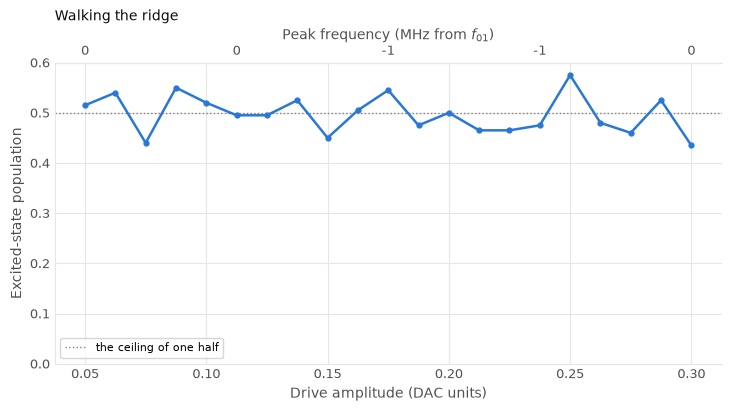

coords['drive_freq'] names a coordinate this figure does not draw. This line draws: 'drive_amp' (the x axis). The measured quantity is not keyed here — name it with value=Quantity(...). Coordinates on this result: drive_amp, drive_freq.


In [31]:
ax_ridge = ridge_result.plot(
    m_ridge,
    field=MeasurementField.STATE,
    coords={"drive_freq": Quantity("Peak frequency", "MHz from $f_{01}$", lambda v: (v - F01) / 1e6)},
    value=Quantity("Excited-state population"),
    style=Style(markers=True),
    title="Walking the ridge",
)
ax_ridge.set_ylim(0.0, 0.6)
ax_ridge.axhline(0.5, color="grey", ls=":", lw=1, label="the ceiling of one half")
ax_ridge.legend(fontsize=8)
plt.show()

try:
    ridge_result.plot(m_ridge, field=MeasurementField.STATE, x="drive_amp",
                      coords={"drive_freq": Quantity(units="Hz")})
except qp.ValidationError as exc:
    print(exc)

### 🧩 Exercise 2.1

Take a cut through the map. Section 2.8 stepped the drive amplitude and the drive frequency over a rectangle. Park the frequency on the transition instead and step the amplitude alone, far enough to drive the qubit all the way over and back.

A drive left on resonance rotates the qubit at a rate proportional to its amplitude, so the population follows $\sin^2$ rather than the saturated Lorentzian of 2.8. The model below is that curve, peaking at `A_PI` by construction.

1. Build a `qp.QProgram` with `label="rabi"` and the `schema` in scope. Declare `amp` with `label="Drive amplitude"` and `units="DAC units"`.
2. Wrap the experiment in `average(shots=200)` and sweep `amp` with a 41-point `qp.Linspace` from 0.0 to 1.0.
3. Inside the loop, `set_frequency` the drive bus to `F01`, then `play` an `IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.15)` on it. The variable goes inside the waveform, as in section 2.8.
4. `sync` the drive and readout buses, then `measure` the readout bus with the `"readout"` and `"weights"` aliases and `fields=(MeasurementField.STATE,)`.
5. Run it with `qp.MockMeasurementModel(p_excited=p_rabi, seed=17)` and print the dims and shape of the state array.
6. Take the swept amplitudes off the array with `rabi_pop.coords["amp"].values`, since `amps` is already in scope from section 2.8 and holds that map's twenty-one values. Then read the calibration off the rising branch rather than off the peak: keep the amplitudes at or below 0.5, find the one whose population sits closest to a half, and double it. Print that beside `A_PI`.
7. Draw it with `style=Style(markers=True)` and `value=Quantity("Excited-state population")`, then put a dashed line on the returned axes at the amplitude you found.

Step 6 is the interesting one. The top of a $\sin^2$ curve is flat, so shot noise moves an `argmax` a step or two off the true peak. The half-way crossing sits on the steepest part of the same curve, where the same noise usually leaves the answer on the grid point the noiseless curve picks. The amplitude axis needs no `coords=` at all, because DAC units are the units the program already declared.

In [32]:
def p_rabi(bus, env):
    """A drive on resonance rotates the qubit, so the population follows a sine squared in amplitude."""
    return np.sin(np.pi * env["amp"] / (2 * A_PI)) ** 2

dims: ('amp',) shape: (41,)
half rotation at 0.300, so a full one at 0.600
true A_PI 0.620, grid step 0.025


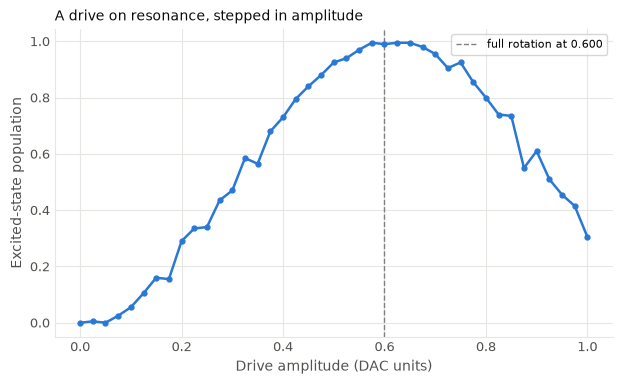

In [33]:
rabi = qp.QProgram(label="rabi", schema=schema)
r_pulse_amp = rabi.variable("amp", label="Drive amplitude", units="DAC units")

with rabi.average(shots=200):
    with rabi.sweep(r_pulse_amp, qp.Linspace(0.0, 1.0, 41)):
        rabi.set_frequency(q[0].drive, F01)
        rabi.play(q[0].drive, IQDrag(amplitude=r_pulse_amp, duration=40, sigma=10, beta=0.15))
        rabi.sync([q[0].drive, q[0].readout])
        m_rabi = rabi.measure(q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,))

rabi_result = qp.simulate(rabi, model=qp.MockMeasurementModel(p_excited=p_rabi, seed=17))
rabi_pop = rabi_result.get(m_rabi, field=MeasurementField.STATE)
rabi_amps = rabi_pop.coords["amp"].values

rising = rabi_amps <= 0.5  # the first half of the sweep, before the curve turns over
half_amp = float(rabi_amps[rising][np.abs(rabi_pop.values[rising] - 0.5).argmin()])
a_pi_found = 2 * half_amp

print("dims:", rabi_pop.dims, "shape:", rabi_pop.shape)
print(f"half rotation at {half_amp:.3f}, so a full one at {a_pi_found:.3f}")
print(f"true A_PI {A_PI:.3f}, grid step {rabi_amps[1] - rabi_amps[0]:.3f}")

ax_rabi = rabi_result.plot(
    m_rabi,
    field=MeasurementField.STATE,
    value=Quantity("Excited-state population"),
    style=Style(markers=True),
    title="A drive on resonance, stepped in amplitude",
)
ax_rabi.axvline(a_pi_found, color="grey", ls="--", lw=1, label=f"full rotation at {a_pi_found:.3f}")
ax_rabi.legend(fontsize=8)
plt.show()

## Recap

- A **variable** is a hole in the program, declared with `program.variable(id, label=..., units=...)`. The label and the units follow the data out and name the axes of every figure, so declaring them once is the whole of plot labeling.
- **Arithmetic on a variable builds a tree and computes nothing.** The tree re-evaluates every iteration, it may go anywhere QProgram takes a number, and it reaches a pulse through a waveform's constructor.
- A **sweep source** says how the variable moves, and a sweep has two spellings: a source object, or a `from_*` builder. A bare list is refused, because a source answers its length and its kind before anything runs. `qp.Range` and `qp.Linspace` are linear, so an instrument can generate their points itself, and everything else is arbitrary.
- **`average(shots)` adds no dimension.** It shrinks the noise on the integrated point, it turns the classified state from a 0 or a 1 into a population, and it still adds a level to the repetition depth a machine has to support.
- The **measurement model** is where every measured number in a run comes from. `qp.MockMeasurementModel` covers most cases and any object with a `sample(bus, env)` method covers the rest.
- **Results are xarray.** One dimension per enclosing sweep, outermost first, named after your variable ids, plus an `IQ` axis, plus one shared `"a|b"` dimension for a lockstep pair. `get` takes a handle, a name, or an integer, and `result.plot` picks a line for one swept dimension and a heatmap for two, then hands back the `Axes` your reference lines go on.

## Next

**Advanced.** Six sections on extending the language and on describing the machine that runs it. Each one stands on its own, so read them in whatever order your rack makes urgent.